In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
df=pd.read_csv("Salary Data.csv")

In [69]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [70]:
df.isna().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [71]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [72]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Education Level'] = df['Education Level'].fillna(df['Education Level'].mode()[0])
df['Job Title'] = df['Job Title'].fillna(df['Job Title'].mode()[0])
df['Years of Experience'] = df['Years of Experience'].fillna(df['Years of Experience'].median())
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

In [73]:
df.isna().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [74]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


<Axes: xlabel='Salary'>

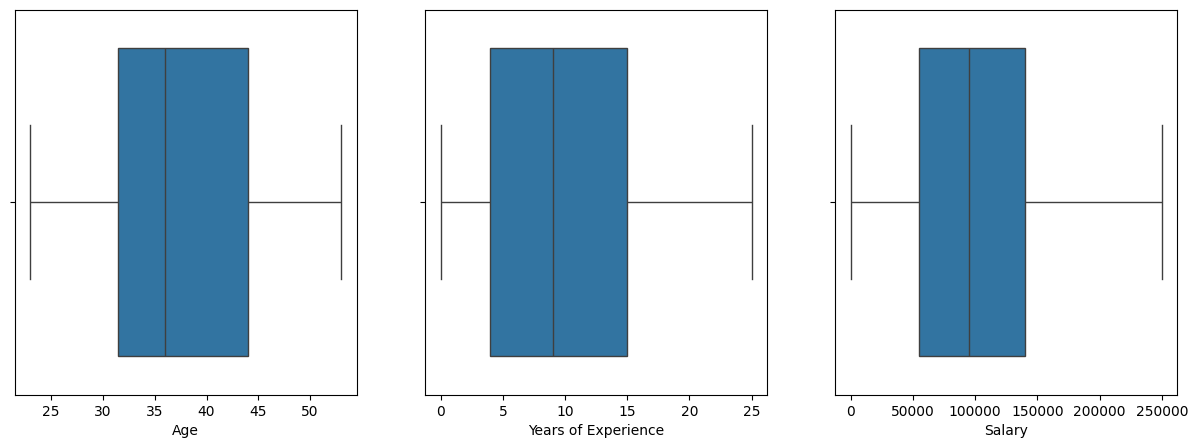

In [75]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.boxplot(data=df,x='Age')

plt.subplot(1,3,2)
sns.boxplot(data=df,x='Years of Experience')

plt.subplot(1,3,3)
sns.boxplot(data=df,x='Salary')


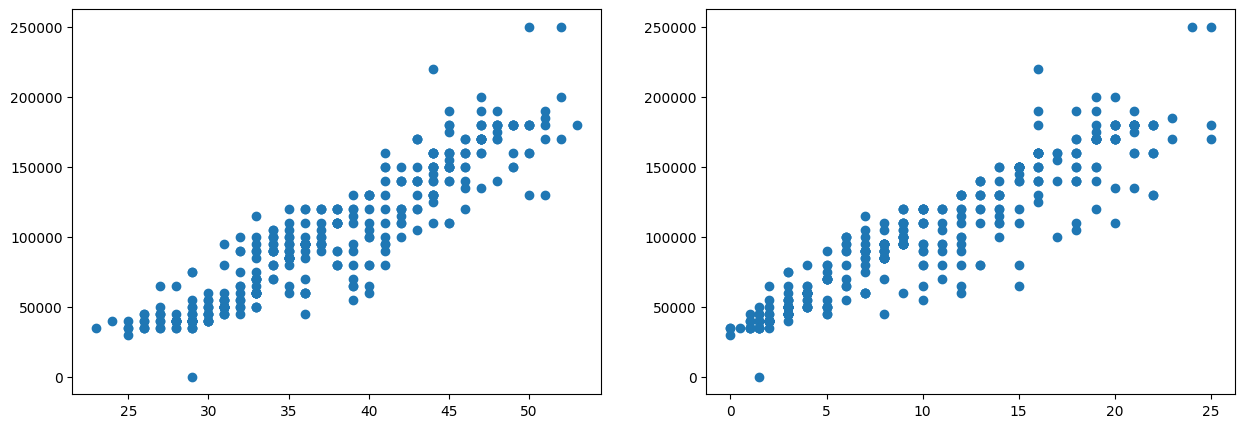

In [76]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.scatter(data=df,x='Age',y='Salary')

plt.subplot(1,2,2)
plt.scatter(data=df,x='Years of Experience',y='Salary')




In [77]:
X=df.drop('Salary',axis=1)
y = df['Salary']

In [78]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [79]:
cat_features = X.select_dtypes(include='object').columns
num_features = X.select_dtypes(exclude='object').columns

ordinal_features = ['Education Level']
nominal_features = [col for col in cat_features if col not in ordinal_features]

print(ordinal_features)
print(nominal_features)

['Education Level']
['Gender', 'Job Title']


In [80]:
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
oe=OrdinalEncoder()
ohe=OneHotEncoder(handle_unknown='ignore')
scaler = StandardScaler()

preprocessor = ColumnTransformer([
                        ('oe',oe,ordinal_features),
                        ('ohe',ohe,nominal_features),
                        ('scaler',scaler,num_features)
                                  ],remainder='passthrough')


In [81]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [82]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X_train)

cum_var = np.cumsum(pca.explained_variance_ratio_)
n_components = np.argmax(cum_var >= 0.95) + 1

print("Components for 95% variance:", n_components)

Components for 95% variance: 89


In [83]:
pca = PCA(n_components=89)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

In [84]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,root_mean_squared_error

In [85]:
models = {
    'LinearRegression' : LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet' : ElasticNet(),
    'SVR' : SVR(),
    'RandomForestRegressor' : RandomForestRegressor(),
    'AdaBoostRegressor' : AdaBoostRegressor(),
    'DecisionTreeRegressor' : DecisionTreeRegressor(),
    'GradientBoostingRegressor' : GradientBoostingRegressor(),
    'XGBRegressor' : XGBRegressor(),
    'CatBoostRegressor' : CatBoostRegressor()
}

model_list = []
r2_list = []

for i in range (len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_trained_r2 = r2_score(y_train,y_train_pred)
    model_trained_mse = mean_squared_error(y_train,y_train_pred)
    model_trained_mae = mean_squared_error(y_train,y_train_pred)
    model_trained_rmse = root_mean_squared_error(y_train,y_train_pred)

    model_tested_r2 = r2_score(y_test,y_test_pred)
    model_tested_mse = mean_squared_error(y_test,y_test_pred)
    model_tested_mae = mean_squared_error(y_test,y_test_pred)
    model_tested_rmse = root_mean_squared_error(y_test,y_test_pred)

    print(list(models.keys())[i])

    print("MODEL PERFORMANCE ON TRAINING DATASET")
    print(f"- R2 Score : {model_trained_r2:.4f}")
    print(f"- Mean Squared Error : {model_trained_mse:.4f}")
    print(f"- Mean Absolute Error : {model_trained_mae:.4f}")
    print(f"- Root Mean Squared Error : {model_trained_rmse:.4f}")

    print("---------------------------------------")

    print("MODEL PERFORMANCE ON TEST DATASET")
    print(f"- R2 Score : {model_tested_r2:.4f}")
    print(f"- Mean Squared Error : {model_tested_mse:.4f}")
    print(f"- Mean Absolute Error : {model_tested_mae:.4f}")
    print(f"- Root Mean Squared Error : {model_tested_rmse:.4f}")
    print('='*35)
    print('\n')

    model_list.append(list(models.keys())[i])
    r2_list.append(model_tested_r2)


LinearRegression
MODEL PERFORMANCE ON TRAINING DATASET
- R2 Score : 0.9501
- Mean Squared Error : 116976200.6684
- Mean Absolute Error : 116976200.6684
- Root Mean Squared Error : 10815.5536
---------------------------------------
MODEL PERFORMANCE ON TEST DATASET
- R2 Score : 0.8933
- Mean Squared Error : 235529899.6105
- Mean Absolute Error : 235529899.6105
- Root Mean Squared Error : 15346.9834


Ridge
MODEL PERFORMANCE ON TRAINING DATASET
- R2 Score : 0.9449
- Mean Squared Error : 128959071.1908
- Mean Absolute Error : 128959071.1908
- Root Mean Squared Error : 11356.0148
---------------------------------------
MODEL PERFORMANCE ON TEST DATASET
- R2 Score : 0.8963
- Mean Squared Error : 228953053.4832
- Mean Absolute Error : 228953053.4832
- Root Mean Squared Error : 15131.1947


Lasso
MODEL PERFORMANCE ON TRAINING DATASET
- R2 Score : 0.9501
- Mean Squared Error : 116990105.6742
- Mean Absolute Error : 116990105.6742
- Root Mean Squared Error : 10816.1965
-------------------------

In [86]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model_Name','R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model_Name,R2_Score
1,Ridge,0.896260
2,Lasso,0.893383
0,LinearRegression,0.893280
3,ElasticNet,0.869063
10,CatBoostRegressor,0.868427
8,GradientBoostingRegressor,0.857684
5,RandomForestRegressor,0.857060
6,AdaBoostRegressor,0.856986
9,XGBRegressor,0.816163
7,DecisionTreeRegressor,0.802249
